# Python Lesson 26: Eigenvalues and Eigenvectors

**Concept page:** `wiki/concepts/eigenvalues-and-eigenvectors.md` · **Area:** linear-algebra

**You will be able to:**
- find eigenpairs by characteristic polynomial and np.linalg.eig
- check A v = λ v
- see eigenvectors as invariant directions
- use them for PCA

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. By hand with SymPy

In [2]:
lam=sp.symbols('lambda'); A=sp.Matrix([[9,4],[4,3]])
print(sp.factor((A-lam*sp.eye(2)).det()))   # (lambda-11)(lambda-1)
print(A.eigenvects())

(lambda - 11)*(lambda - 1)
[(1, 1, [Matrix([
[-1/2],
[   1]])]), (11, 1, [Matrix([
[2],
[1]])])]


## 2. NumPy and the check

In [3]:
A=np.array([[2,1],[0,3]],float); w,V=np.linalg.eig(A); print(w); print(V)
for i in range(2): print(np.allclose(A@V[:,i],w[i]*V[:,i]))

[2. 3.]
[[1.     0.7071]
 [0.     0.7071]]
True
True


## 3. Picture: eigenvectors keep their direction

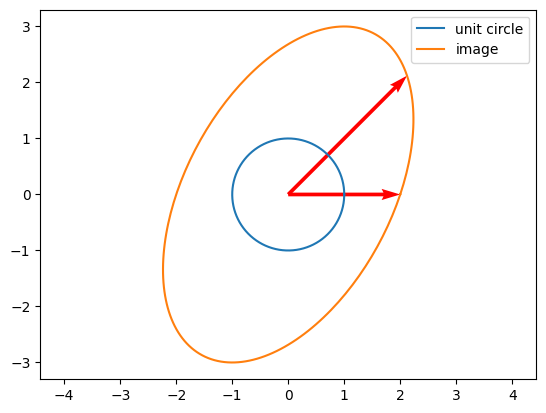

In [4]:
th=np.linspace(0,2*np.pi,200); circ=np.array([np.cos(th),np.sin(th)]); img=A@circ
plt.plot(*circ,label='unit circle'); plt.plot(*img,label='image')
for i in range(2): plt.quiver(0,0,*(w[i]*V[:,i]),angles='xy',scale_units='xy',scale=1,color='r')
plt.axis('equal'); plt.legend(); plt.show()

## 4. PCA = eigenvectors of the covariance matrix

In [5]:
rng=np.random.default_rng(0); X=rng.normal(size=(500,2))@np.array([[3,1],[0,1]])
C=np.cov(X.T); vals,vecs=np.linalg.eigh(C); print("variances along PCs:",vals[::-1]); print("first PC:",vecs[:,-1])

variances along PCs: [9.8255 0.834 ]
first PC: [-0.9376 -0.3477]


## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 11 advanced: *fixed points* A(Q)=Q are eigenvectors with λ = 1 — check on the matrix with λ=1 direction.

In [6]:
M=np.array([[1,0],[0,-1]]); w,V=np.linalg.eig(M); print(w, V[:,0])

[ 1. -1.] [1. 0.]


## Exercises

**Exercise 1.** Eigenvalues of [[2,0],[0,5]] and of the rotation by 90 degrees (complex).

In [7]:
# your code here

**Exercise 2.** Verify trace = sum of eigenvalues and det = product for a random 3x3.

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
print(np.linalg.eigvals([[2,0],[0,5]]), np.linalg.eigvals([[0,-1],[1,0]]))

[2. 5.] [0.+1.j 0.-1.j]


In [10]:
# Solution 2
rng=np.random.default_rng(0);M=rng.normal(size=(3,3));w=np.linalg.eigvals(M); assert np.isclose(np.trace(M),w.sum().real) and np.isclose(np.linalg.det(M),np.prod(w).real)